In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm

# ============================================================
# USER INPUTS
# ============================================================
UCDB_GPKG = Path(r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\GHS_STAT_UCDB2015MT_GLOBE_R2019A\GHS_STAT_UCDB2015MT_GLOBE_R2019A_V1_2_with_GHSPOP2023.gpkg")

PREDICTIONS_FOLDER = Path(r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\predictions")

# UCDB columns
UCDB_ID_COL = "ID_HDC_G0"
UCDB_POP_COL = "GHSPOP2023"
UCDB_REGION_COL = "GRGN_L1"

# CitySegments columns
CITY_COL = "UC_NM_MN"        # city name/label used for QC grouping
CS_REGION_COL = "REG1_GHSL"
CS_POP_COL = "POP_SEG"
RF_LABEL_COL = "rf_label"

# Keep only these regions
TARGET_REGIONS = ["Asia", "Africa", "Latin America and the Caribbean"]

# Quality requirement
VALID_BLOCKS_THRESHOLD = 80.0  # %

# Output CSV
OUT_CSV = PREDICTIONS_FOLDER / "city_size_comparison_QC80_Africa_Asia_LAC_millions.csv"



In [2]:
# ============================================================
# City size classifier
# ============================================================
def classify_city_size(pop):
    pop = 0 if pd.isna(pop) else float(pop)
    if pop < 500_000:
        return "Small"
    elif pop < 1_000_000:
        return "Medium"
    elif pop < 5_000_000:
        return "Large"
    elif pop < 10_000_000:
        return "Very large"
    else:
        return "Megacity"


SIZE_ORDER = ["Small", "Medium", "Large", "Very large", "Megacity"]

In [3]:
# ============================================================
# 1) Load UCDB (ID, region, pop) and filter regions
# ============================================================
ucdb_layer = gpd.list_layers(UCDB_GPKG).iloc[0]["name"]
ucdb = gpd.read_file(
    UCDB_GPKG,
    layer=ucdb_layer,
    columns=[UCDB_ID_COL, UCDB_REGION_COL, UCDB_POP_COL]
)

ucdb[UCDB_ID_COL] = ucdb[UCDB_ID_COL].astype(str)

ucdb_unique = (
    ucdb[[UCDB_ID_COL, UCDB_REGION_COL, UCDB_POP_COL]]
    .dropna(subset=[UCDB_ID_COL])
    .drop_duplicates(subset=[UCDB_ID_COL])
)

ucdb_unique = ucdb_unique[ucdb_unique[UCDB_REGION_COL].isin(TARGET_REGIONS)].copy()
ucdb_unique["CitySizeClass"] = ucdb_unique[UCDB_POP_COL].apply(classify_city_size)

print("UCDB unique cities (filtered):", len(ucdb_unique))
print("UCDB regions present:", sorted(ucdb_unique[UCDB_REGION_COL].dropna().unique().tolist()))


UCDB unique cities (filtered): 11618
UCDB regions present: ['Africa', 'Asia', 'Latin America and the Caribbean']


In [4]:
# ============================================================
# 2) Build CitySegments city-level table with QC (>=80% valid blocks)
# ============================================================
records = []

gpkg_files = sorted(PREDICTIONS_FOLDER.rglob("*.gpkg"))
print("CitySegments GPKGs found:", len(gpkg_files))

for fp in tqdm(gpkg_files, desc="Reading CitySegments GPKGs"):
    country = fp.stem  # fallback
    # If your naming is like "{country}_rf_preds.gpkg", uncomment:
    # country = fp.stem.replace("_rf_preds", "")

    try:
        layer = gpd.list_layers(fp).iloc[0]["name"]
        gdf = gpd.read_file(
            fp,
            layer=layer,
            columns=[CS_REGION_COL, CITY_COL, RF_LABEL_COL, CS_POP_COL]
        )
    except Exception as e:
        print(f"⚠️ Skipping {fp.name} due to error: {e}")
        continue

    # Filter to target regions early
    gdf = gdf[gdf[CS_REGION_COL].isin(TARGET_REGIONS)].copy()
    if gdf.empty:
        continue

    # valid block = both rf_label and POP_SEG present
    gdf["valid"] = ~(gdf[RF_LABEL_COL].isna() | gdf[CS_POP_COL].isna())

    # Group by city label
    for city, sub in gdf.groupby(CITY_COL, dropna=True):
        total_blocks = len(sub)
        if total_blocks == 0:
            continue

        valid_blocks = int(sub["valid"].sum())
        pct_valid = (valid_blocks / total_blocks) * 100.0

        if pct_valid < VALID_BLOCKS_THRESHOLD:
            continue  # fail QC

        sub_valid = sub[sub["valid"]]

        total_pop = float(sub_valid[CS_POP_COL].sum())
        deprived_pop = float(sub_valid.loc[sub_valid[RF_LABEL_COL] == 1, CS_POP_COL].sum())

        records.append({
            "Region": sub[CS_REGION_COL].iloc[0],
            "Country": country,
            "City": city,
            "TotalBlocks": total_blocks,
            "ValidBlocks": valid_blocks,
            "PctValid": pct_valid,
            "TotalPop": total_pop,
            "DeprivedPop": deprived_pop,
        })

city_df = pd.DataFrame(records)
print(f"Cities passing QC (>= {VALID_BLOCKS_THRESHOLD:.1f}% valid blocks):", len(city_df))

# Add city size class (based on QC-passed TotalPop)
city_df["CitySizeClass"] = city_df["TotalPop"].apply(classify_city_size)


CitySegments GPKGs found: 107


Reading CitySegments GPKGs: 100%|██████████| 107/107 [00:11<00:00,  9.50it/s]

Cities passing QC (>= 80.0% valid blocks): 5132


In [5]:
# ============================================================
# 3) Aggregate both datasets by CitySizeClass (global, filtered regions only)
# ============================================================
ucdb_size = (
    ucdb_unique
    .groupby("CitySizeClass", as_index=False)
    .agg(
        UCDB_Cities=(UCDB_ID_COL, "nunique"),
        UCDB_Total_Pop=(UCDB_POP_COL, "sum")
    )
)

cityseg_size = (
    city_df
    .groupby("CitySizeClass", as_index=False)
    .agg(
        CitySegments_Cities=("City", "nunique"),
        CitySegments_Total_Pop=("TotalPop", "sum"),
        CitySegments_Deprived_Pop=("DeprivedPop", "sum")
    )
)

size_comparison = pd.merge(ucdb_size, cityseg_size, on="CitySizeClass", how="outer").fillna(0)

# Coverage + deprivation metrics
size_comparison["City_Coverage_%"] = (
    size_comparison["CitySegments_Cities"] /
    size_comparison["UCDB_Cities"].replace(0, pd.NA)
) * 100

size_comparison["Population_Coverage_%"] = (
    size_comparison["CitySegments_Total_Pop"] /
    size_comparison["UCDB_Total_Pop"].replace(0, pd.NA)
) * 100

size_comparison["Deprivation_Rate_%"] = (
    size_comparison["CitySegments_Deprived_Pop"] /
    size_comparison["CitySegments_Total_Pop"].replace(0, pd.NA)
) * 100

# Order size classes
size_comparison["CitySizeClass"] = pd.Categorical(
    size_comparison["CitySizeClass"],
    categories=SIZE_ORDER,
    ordered=True
)
size_comparison = size_comparison.sort_values("CitySizeClass")


In [6]:
# ============================================================
# 4) Prepare export: populations in millions + rounding
# ============================================================
export_df = size_comparison.copy()

for col in ["UCDB_Total_Pop", "CitySegments_Total_Pop", "CitySegments_Deprived_Pop"]:
    export_df[col] = (export_df[col] / 1_000_000).round(2)

export_df = export_df.rename(columns={
    "UCDB_Total_Pop": "UCDB_Total_Pop_Millions",
    "CitySegments_Total_Pop": "CitySegments_Total_Pop_Millions",
    "CitySegments_Deprived_Pop": "CitySegments_Deprived_Pop_Millions",
})

for col in ["City_Coverage_%", "Population_Coverage_%", "Deprivation_Rate_%"]:
    export_df[col] = export_df[col].round(2)

export_df

,CitySizeClass,UCDB_Cities,UCDB_Total_Pop_Millions,CitySegments_Cities,CitySegments_Total_Pop_Millions,CitySegments_Deprived_Pop_Millions,City_Coverage_%,Population_Coverage_%,Deprivation_Rate_%
3,Small,10744,1113.72,4510,642.01,102.33,41.98,57.65,15.94
1,Medium,451,312.12,283,196.90,33.90,62.75,63.09,17.22
0,Large,351,727.91,252,521.36,111.90,71.79,71.62,21.46
4,Very large,40,276.64,25,170.84,49.50,62.50,61.75,28.98
2,Megacity,32,626.89,23,427.48,97.31,71.88,68.19,22.76


In [7]:
# ============================================================
# 5) Save CSV
# ============================================================
export_df.to_csv(OUT_CSV, index=False)
print("✅ Saved CSV to:", OUT_CSV)

✅ Saved CSV to: D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\predictions\city_size_comparison_QC80_Africa_Asia_LAC_millions.csv


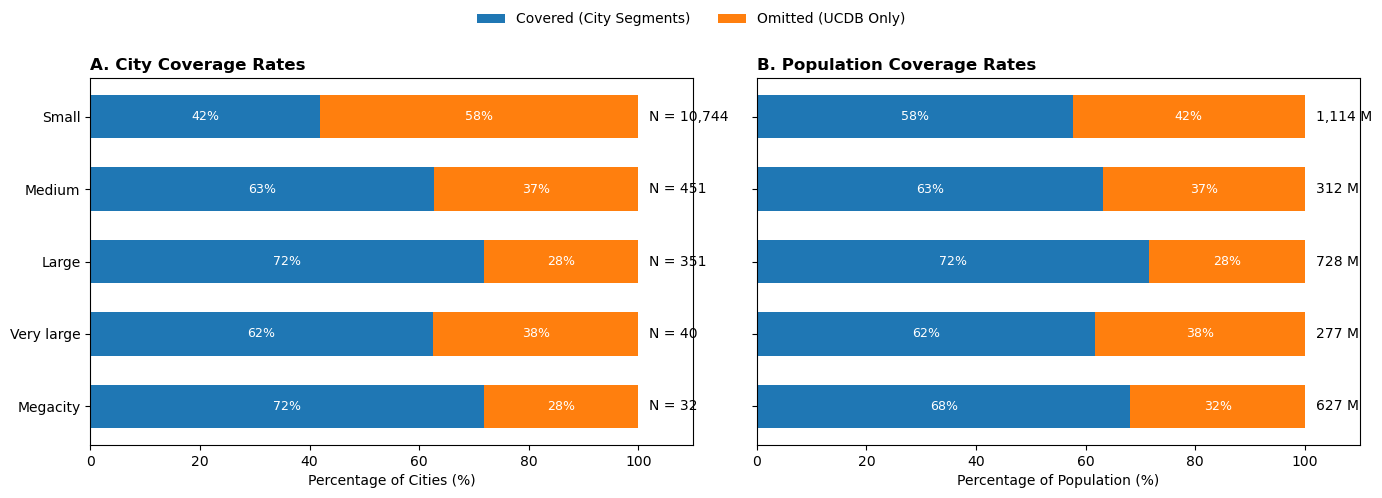

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------------------------
# LOAD CSV
# -------------------------------------------------
CSV_PATH = Path(r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\city_size_comparison_QC80_Africa_Asia_LAC_millions.csv")

df = pd.read_csv(CSV_PATH)

# -------------------------------------------------
# Restore absolute population values (millions → absolute)
# -------------------------------------------------
df["UCDB_Total_Pop"] = df["UCDB_Total_Pop_Millions"] * 1_000_000
df["CitySegments_Total_Pop"] = df["CitySegments_Total_Pop_Millions"] * 1_000_000

# -------------------------------------------------
# Compute covered / omitted
# -------------------------------------------------
df["Cities_Covered"] = df["CitySegments_Cities"]
df["Cities_Omitted"] = df["UCDB_Cities"] - df["CitySegments_Cities"]

df["Pop_Covered"] = df["CitySegments_Total_Pop"]
df["Pop_Omitted"] = df["UCDB_Total_Pop"] - df["CitySegments_Total_Pop"]

# Percentages
df["Cities_Covered_pct"] = np.where(df["UCDB_Cities"] > 0,
                                    df["Cities_Covered"] / df["UCDB_Cities"] * 100, 0)

df["Cities_Omitted_pct"] = 100 - df["Cities_Covered_pct"]

df["Pop_Covered_pct"] = np.where(df["UCDB_Total_Pop"] > 0,
                                 df["Pop_Covered"] / df["UCDB_Total_Pop"] * 100, 0)

df["Pop_Omitted_pct"] = 100 - df["Pop_Covered_pct"]

# Labels for right side
df["N_label"] = df["UCDB_Cities"].astype(int).map(lambda x: f"N = {x:,}")
df["Pop_label"] = df["UCDB_Total_Pop_Millions"].round(0).astype(int).map(lambda x: f"{x:,} M")

# Order size classes
size_order = ["Small", "Medium", "Large", "Very large", "Megacity"]
df["CitySizeClass"] = pd.Categorical(df["CitySizeClass"], categories=size_order, ordered=True)
df = df.sort_values("CitySizeClass").reset_index(drop=True)

# -------------------------------------------------
# PLOTTING
# -------------------------------------------------
y = np.arange(len(df))
bar_h = 0.6

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ===============================
# A) City Coverage
# ===============================
ax = axes[0]

bars1 = ax.barh(y, df["Cities_Covered_pct"], height=bar_h)
bars2 = ax.barh(y, df["Cities_Omitted_pct"],
                left=df["Cities_Covered_pct"],
                height=bar_h)

ax.set_yticks(y)
ax.set_yticklabels(df["CitySizeClass"])
ax.invert_yaxis()
ax.set_xlim(0, 110)
ax.set_xlabel("Percentage of Cities (%)")
ax.set_title("A. City Coverage Rates", loc="left", fontweight="bold")

# Add percentage labels inside stacks
for i in range(len(df)):
    # Covered
    if df["Cities_Covered_pct"][i] > 5:
        ax.text(df["Cities_Covered_pct"][i] / 2,
                i,
                f"{df['Cities_Covered_pct'][i]:.0f}%",
                ha="center", va="center", color="white", fontsize=9)

    # Omitted
    if df["Cities_Omitted_pct"][i] > 5:
        ax.text(df["Cities_Covered_pct"][i] + df["Cities_Omitted_pct"][i] / 2,
                i,
                f"{df['Cities_Omitted_pct'][i]:.0f}%",
                ha="center", va="center", color="white", fontsize=9)

# Right-side N labels
for i, lab in enumerate(df["N_label"]):
    ax.text(102, i, lab, va="center", ha="left")

# ===============================
# B) Population Coverage
# ===============================
ax2 = axes[1]

bars3 = ax2.barh(y, df["Pop_Covered_pct"], height=bar_h)
bars4 = ax2.barh(y, df["Pop_Omitted_pct"],
                 left=df["Pop_Covered_pct"],
                 height=bar_h)

ax2.set_xlim(0, 110)
ax2.set_xlabel("Percentage of Population (%)")
ax2.set_title("B. Population Coverage Rates", loc="left", fontweight="bold")

# Add percentage labels inside stacks
for i in range(len(df)):
    # Covered
    if df["Pop_Covered_pct"][i] > 5:
        ax2.text(df["Pop_Covered_pct"][i] / 2,
                 i,
                 f"{df['Pop_Covered_pct'][i]:.0f}%",
                 ha="center", va="center", color="white", fontsize=9)

    # Omitted
    if df["Pop_Omitted_pct"][i] > 5:
        ax2.text(df["Pop_Covered_pct"][i] + df["Pop_Omitted_pct"][i] / 2,
                 i,
                 f"{df['Pop_Omitted_pct'][i]:.0f}%",
                 ha="center", va="center", color="white", fontsize=9)

# Right-side population labels
for i, lab in enumerate(df["Pop_label"]):
    ax2.text(102, i, lab, va="center", ha="left")

# Shared legend
fig.legend(["Covered (City Segments)", "Omitted (UCDB Only)"],
           loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

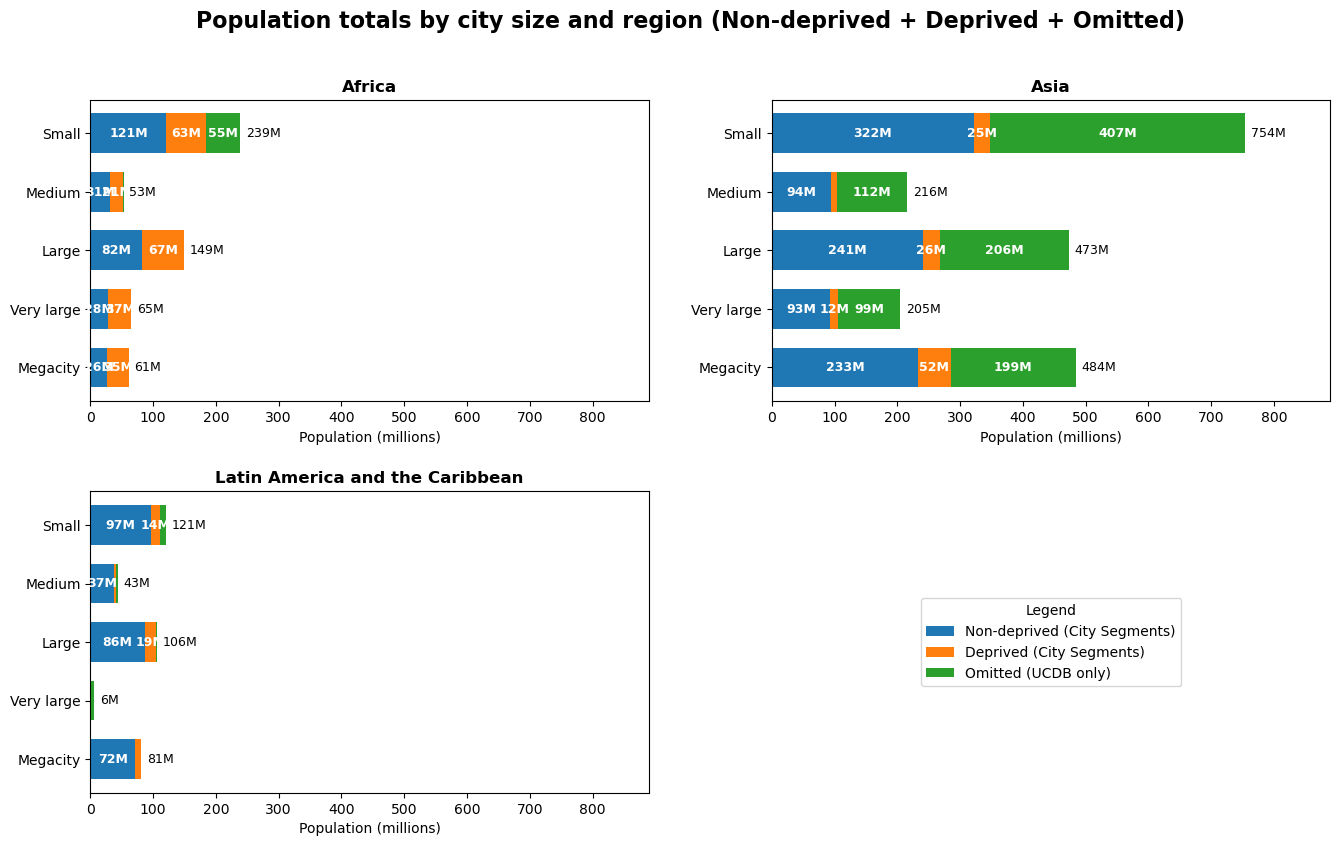

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------------------------
# INPUTS
# -------------------------------------------------
UCDB_GPKG = Path(r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\GHS_STAT_UCDB2015MT_GLOBE_R2019A\GHS_STAT_UCDB2015MT_GLOBE_R2019A_V1_2_with_GHSPOP2023.gpkg")
CITY_QC_CSV = Path(r"D:\VSG\DIRTY_MODEL\February2026\csmd_model_v2\2_modelling\02_application\summary_statistics\city_deprivation_80pct.csv")

UCDB_ID_COL = "ID_HDC_G0"
UCDB_REGION_COL = "GRGN_L1"
UCDB_POP_COL = "GHSPOP2023"

TARGET_REGIONS = ["Africa", "Asia", "Latin America and the Caribbean"]
REGION_TITLES = {
    "Africa": "Africa",
    "Asia": "Asia",
    "Latin America and the Caribbean": "Latin America and the Caribbean"
}

SIZE_ORDER = ["Small", "Medium", "Large", "Very large", "Megacity"]

# -------------------------------------------------
# City size classifier (same thresholds)
# -------------------------------------------------
def classify_city_size(pop):
    pop = 0 if pd.isna(pop) else float(pop)
    if pop < 500_000:
        return "Small"
    elif pop < 1_000_000:
        return "Medium"
    elif pop < 5_000_000:
        return "Large"
    elif pop < 10_000_000:
        return "Very large"
    else:
        return "Megacity"

# =================================================
# 1) UCDB totals by Region × CitySize (population)
# =================================================
ucdb_layer = gpd.list_layers(UCDB_GPKG).iloc[0]["name"]
ucdb = gpd.read_file(
    UCDB_GPKG,
    layer=ucdb_layer,
    columns=[UCDB_ID_COL, UCDB_REGION_COL, UCDB_POP_COL]
)
ucdb[UCDB_ID_COL] = ucdb[UCDB_ID_COL].astype(str)

ucdb_unique = (
    ucdb[[UCDB_ID_COL, UCDB_REGION_COL, UCDB_POP_COL]]
    .dropna(subset=[UCDB_ID_COL])
    .drop_duplicates(subset=[UCDB_ID_COL])
)

ucdb_unique = ucdb_unique[ucdb_unique[UCDB_REGION_COL].isin(TARGET_REGIONS)].copy()
ucdb_unique["CitySizeClass"] = ucdb_unique[UCDB_POP_COL].apply(classify_city_size)

ucdb_reg_size = (
    ucdb_unique
    .groupby([UCDB_REGION_COL, "CitySizeClass"], as_index=False)
    .agg(UCDB_TotalPop=(UCDB_POP_COL, "sum"))
).rename(columns={UCDB_REGION_COL: "Region"})

# =================================================
# 2) CitySegments QC city-level totals by Region × CitySize
#    Expect CSV columns: Region, TotalPop, DeprivedPop
# =================================================
city_df = pd.read_csv(CITY_QC_CSV)

# Restrict to target regions
city_df = city_df[city_df["Region"].isin(TARGET_REGIONS)].copy()

# Add city size class (based on CitySegments city total pop)
city_df["CitySizeClass"] = city_df["TotalPop"].apply(classify_city_size)

cs_reg_size = (
    city_df
    .groupby(["Region", "CitySizeClass"], as_index=False)
    .agg(
        CS_TotalPop=("TotalPop", "sum"),
        CS_DeprivedPop=("DeprivedPop", "sum")
    )
)
cs_reg_size["CS_NonDeprivedPop"] = (cs_reg_size["CS_TotalPop"] - cs_reg_size["CS_DeprivedPop"]).clip(lower=0)

# =================================================
# 3) Merge + compute omitted = UCDB - CS
# =================================================
merged = pd.merge(
    ucdb_reg_size,
    cs_reg_size,
    on=["Region", "CitySizeClass"],
    how="left"
)

for c in ["CS_TotalPop", "CS_DeprivedPop", "CS_NonDeprivedPop"]:
    merged[c] = merged[c].fillna(0.0)

merged["OmittedPop"] = (merged["UCDB_TotalPop"] - merged["CS_TotalPop"]).clip(lower=0)

# Convert to millions for plotting
for c in ["UCDB_TotalPop", "CS_TotalPop", "CS_DeprivedPop", "CS_NonDeprivedPop", "OmittedPop"]:
    merged[c] = merged[c] / 1_000_000

# Ensure complete grid (Region × Size) so bars always appear in same order
grid = pd.MultiIndex.from_product([TARGET_REGIONS, SIZE_ORDER], names=["Region", "CitySizeClass"]).to_frame(index=False)
merged = pd.merge(grid, merged, on=["Region", "CitySizeClass"], how="left").fillna(0.0)

merged["CitySizeClass"] = pd.Categorical(merged["CitySizeClass"], categories=SIZE_ORDER, ordered=True)
merged["Region"] = pd.Categorical(merged["Region"], categories=TARGET_REGIONS, ordered=True)
merged = merged.sort_values(["Region", "CitySizeClass"]).reset_index(drop=True)

# =================================================
# 4) Plot: faceted stacked bars (totals, millions)
# =================================================
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1], wspace=0.22, hspace=0.30)

axes = {
    "Africa": fig.add_subplot(gs[0, 0]),
    "Asia": fig.add_subplot(gs[0, 1]),
    "Latin America and the Caribbean": fig.add_subplot(gs[1, 0]),
}
ax_legend = fig.add_subplot(gs[1, 1])
ax_legend.axis("off")

# Determine a common x-limit across panels for comparability
max_total = 0.0
for r in TARGET_REGIONS:
    tmp = merged[merged["Region"] == r]
    total = (tmp["CS_NonDeprivedPop"] + tmp["CS_DeprivedPop"] + tmp["OmittedPop"]).max()
    max_total = max(max_total, float(total))

# Add some headroom for labels
xmax = max_total * 1.18 if max_total > 0 else 1.0

def label_stack(ax, left, width, y, text, min_width=8):
    """Label a stack segment if it's wide enough (in data units, i.e., millions)."""
    if width >= min_width:
        ax.text(left + width/2, y, text, ha="center", va="center", fontsize=9, color="white", fontweight="bold")

for region in TARGET_REGIONS:
    ax = axes.get(region, None)
    if ax is None:
        continue

    sub = merged[merged["Region"] == region].copy()

    # y positions: show Megacity at top like your example
    sub = sub.sort_values("CitySizeClass", ascending=False).reset_index(drop=True)
    y = np.arange(len(sub))

    nondep = sub["CS_NonDeprivedPop"].to_numpy()
    dep = sub["CS_DeprivedPop"].to_numpy()
    om = sub["OmittedPop"].to_numpy()

    # Stacked bars (colors left to default? You can set if you want)
    b1 = ax.barh(y, nondep, height=0.68, label="Non-deprived (City Segments)")
    b2 = ax.barh(y, dep, left=nondep, height=0.68, label="Deprived (City Segments)")
    b3 = ax.barh(y, om, left=nondep+dep, height=0.68, label="Omitted (UCDB only)")

    ax.set_yticks(y)
    ax.set_yticklabels(sub["CitySizeClass"])
    ax.set_xlim(0, xmax)
    ax.set_xlabel("Population (millions)")
    ax.set_title(REGION_TITLES[region], fontweight="bold")

    # Segment labels (M). Tune min_width if labels feel cluttered.
    for i in range(len(sub)):
        label_stack(ax, 0, nondep[i], i, f"{nondep[i]:.0f}M", min_width=10)
        label_stack(ax, nondep[i], dep[i], i, f"{dep[i]:.0f}M", min_width=10)
        label_stack(ax, nondep[i]+dep[i], om[i], i, f"{om[i]:.0f}M", min_width=10)

    # Total label at far right
    totals = nondep + dep + om
    for i, tot in enumerate(totals):
        ax.text(tot + xmax*0.01, i, f"{tot:.0f}M", va="center", ha="left", fontsize=9)

# ---- Legend panel (bottom-right)
# Use proxy artists from one of the axes
handles, labels = axes["Africa"].get_legend_handles_labels()
ax_legend.legend(handles, labels, loc="center", frameon=True, title="Legend")

fig.suptitle("Population totals by city size and region (Non-deprived + Deprived + Omitted)", fontsize=16, fontweight="bold", y=0.98)

plt.show()

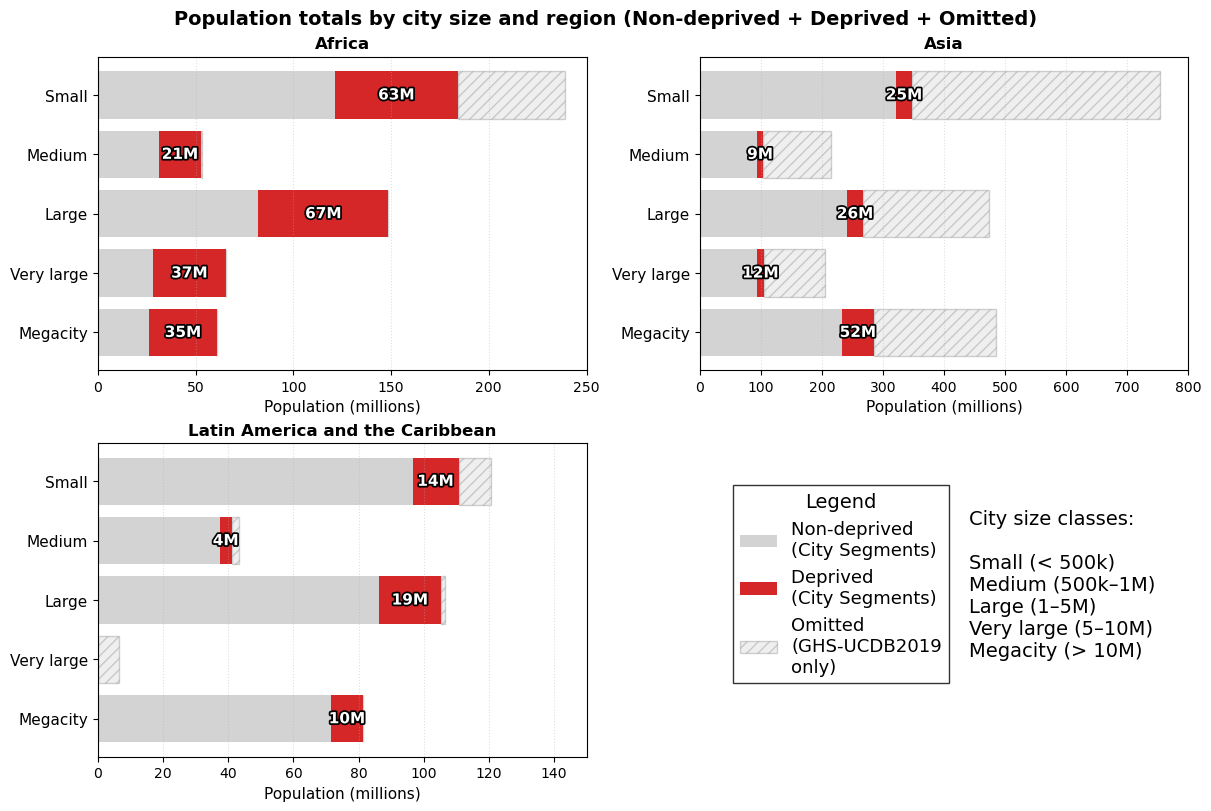

In [22]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from pathlib import Path

# ============================================================
# INPUTS
# ============================================================
UCDB_GPKG = Path(r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis\GHS_STAT_UCDB2015MT_GLOBE_R2019A\GHS_STAT_UCDB2015MT_GLOBE_R2019A_V1_2_with_GHSPOP2023.gpkg")
CITY_QC_CSV = Path(r"D:\VSG\DIRTY_MODEL\February2026\csmd_model_v2\2_modelling\02_application\summary_statistics\city_deprivation_80pct.csv")

UCDB_ID_COL = "ID_HDC_G0"
UCDB_REGION_COL = "GRGN_L1"
UCDB_POP_COL = "GHSPOP2023"

TARGET_REGIONS = ["Africa", "Asia", "Latin America and the Caribbean"]

# Per-panel x-axis maxima (millions)
XMAX_BY_REGION = {
    "Africa": 250,
    "Asia": 800,
    "Latin America and the Caribbean": 150
}

# City size order
ORDER = ["Small", "Medium", "Large", "Very large", "Megacity"]

# ============================================================
# City size classifier (same thresholds)
# ============================================================
def classify_city_size(pop):
    pop = 0 if pd.isna(pop) else float(pop)
    if pop < 500_000:
        return "Small"
    elif pop < 1_000_000:
        return "Medium"
    elif pop < 5_000_000:
        return "Large"
    elif pop < 10_000_000:
        return "Very large"
    else:
        return "Megacity"

# ============================================================
# 1) Build UCDB totals by Region × CitySize (millions)
# ============================================================
ucdb_layer = gpd.list_layers(UCDB_GPKG).iloc[0]["name"]
ucdb = gpd.read_file(
    UCDB_GPKG,
    layer=ucdb_layer,
    columns=[UCDB_ID_COL, UCDB_REGION_COL, UCDB_POP_COL]
)
ucdb[UCDB_ID_COL] = ucdb[UCDB_ID_COL].astype(str)

ucdb_unique = (
    ucdb[[UCDB_ID_COL, UCDB_REGION_COL, UCDB_POP_COL]]
    .dropna(subset=[UCDB_ID_COL])
    .drop_duplicates(subset=[UCDB_ID_COL])
)
ucdb_unique = ucdb_unique[ucdb_unique[UCDB_REGION_COL].isin(TARGET_REGIONS)].copy()
ucdb_unique["CitySizeClass"] = ucdb_unique[UCDB_POP_COL].apply(classify_city_size)

ucdb_reg_size = (
    ucdb_unique
    .groupby([UCDB_REGION_COL, "CitySizeClass"], as_index=False)
    .agg(UCDB_TotalPop=(UCDB_POP_COL, "sum"))
).rename(columns={UCDB_REGION_COL: "Region"})

ucdb_reg_size["UCDB_TotalPop_M"] = ucdb_reg_size["UCDB_TotalPop"] / 1e6

# ============================================================
# 2) Load CitySegments QC city-level data and aggregate to Region × CitySize (millions)
# ============================================================
city_df = pd.read_csv(CITY_QC_CSV)
city_df = city_df[city_df["Region"].isin(TARGET_REGIONS)].copy()

city_df["CitySizeClass"] = city_df["TotalPop"].apply(classify_city_size)

cs_reg_size = (
    city_df
    .groupby(["Region", "CitySizeClass"], as_index=False)
    .agg(
        CS_TotalPop=("TotalPop", "sum"),
        CS_DeprivedPop=("DeprivedPop", "sum")
    )
)

cs_reg_size["CS_NonDeprivedPop"] = (cs_reg_size["CS_TotalPop"] - cs_reg_size["CS_DeprivedPop"]).clip(lower=0)

cs_reg_size["CS_TotalPop_M"] = cs_reg_size["CS_TotalPop"] / 1e6
cs_reg_size["CS_DeprivedPop_M"] = cs_reg_size["CS_DeprivedPop"] / 1e6
cs_reg_size["CS_NonDeprivedPop_M"] = cs_reg_size["CS_NonDeprivedPop"] / 1e6

# ============================================================
# 3) Merge + compute Omitted (millions)
# ============================================================
merged = pd.merge(
    ucdb_reg_size[["Region", "CitySizeClass", "UCDB_TotalPop_M"]],
    cs_reg_size[["Region", "CitySizeClass", "CS_NonDeprivedPop_M", "CS_DeprivedPop_M", "CS_TotalPop_M"]],
    on=["Region", "CitySizeClass"],
    how="left"
)

for c in ["CS_NonDeprivedPop_M", "CS_DeprivedPop_M", "CS_TotalPop_M"]:
    merged[c] = merged[c].fillna(0.0)

merged["OmittedPop_M"] = (merged["UCDB_TotalPop_M"] - merged["CS_TotalPop_M"]).clip(lower=0)

# Ensure complete grid (so every size appears even if 0)
grid = pd.MultiIndex.from_product([TARGET_REGIONS, ORDER], names=["Region", "CitySizeClass"]).to_frame(index=False)
merged = pd.merge(grid, merged, on=["Region", "CitySizeClass"], how="left").fillna(0.0)

merged["CitySizeClass"] = pd.Categorical(merged["CitySizeClass"], categories=ORDER, ordered=True)
merged["Region"] = pd.Categorical(merged["Region"], categories=TARGET_REGIONS, ordered=True)

# ============================================================
# 4) Plotting function (absolute totals; style aligned to your script)
# ============================================================
def plot_region_citysize_totals_on_ax(ax, df, region_name, show_title=True):
    sub = df[df["Region"] == region_name].copy()
    sub = sub.sort_values("CitySizeClass")

    nondep = sub["CS_NonDeprivedPop_M"].to_numpy()
    dep    = sub["CS_DeprivedPop_M"].to_numpy()
    omit   = sub["OmittedPop_M"].to_numpy()

    bars1 = ax.barh(
        sub["CitySizeClass"],
        nondep,
        color="lightgrey",
        height=0.8,
        label="Non-deprived",
    )

    bars2 = ax.barh(
        sub["CitySizeClass"],
        dep,
        left=nondep,
        color="#d62728",
        height=0.8,
        label="Deprived",
    )

    bars3 = ax.barh(
        sub["CitySizeClass"],
        omit,
        left=nondep + dep,
        color="lightgrey",
        alpha=0.35,
        hatch="///",
        edgecolor="grey",
        height=0.8,
        label="Omitted (UCDB only)",
    )

    # === Improved deprived labels (with outline) ===
    for bar, depM, base in zip(bars2, dep, nondep):
        if depM > 2:
            txt = ax.text(
                base + depM / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{depM:.0f}M",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="white",
            )
            txt.set_path_effects([
                pe.Stroke(linewidth=2.5, foreground="black"),
                pe.Normal()
            ])

    if show_title:
        ax.set_title(region_name, fontsize=12, fontweight="bold")

    ax.set_xlim(0, XMAX_BY_REGION.get(region_name, None))
    ax.set_xlabel("Population (millions)", fontsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.invert_yaxis() 

    return bars1, bars2, bars3


# ============================================================
# 5) Build 2x2 figure: Africa, Asia, LAC, Legend panel
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

ax_africa = axes[0, 0]
ax_asia   = axes[0, 1]
ax_lac    = axes[1, 0]
ax_leg    = axes[1, 1]

plot_region_citysize_totals_on_ax(ax_africa, merged, "Africa")
plot_region_citysize_totals_on_ax(ax_asia,   merged, "Asia")
plot_region_citysize_totals_on_ax(ax_lac,    merged, "Latin America and the Caribbean")

# ============================================================
# Improved Legend Panel
# ============================================================
ax_leg.set_axis_off()

legend_handles = [
    Patch(facecolor="lightgrey", edgecolor="none", label="Non-deprived \n(City Segments)"),
    Patch(facecolor="#d62728", edgecolor="none", label="Deprived \n(City Segments)"),
    Patch(facecolor="lightgrey", edgecolor="grey", hatch="///", alpha=0.35, label="Omitted\n(GHS-UCDB2019\nonly)"),
]

leg = ax_leg.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.05, 0.55),  # shifted slightly left
    frameon=True,
    edgecolor="black",
    fancybox=False,
    fontsize=13,   # slightly smaller
    title="Legend",
    title_fontsize=14,
)

citysize_text = (
    "City size classes:\n\n"
    "Small (< 500k)\n"
    "Medium (500k–1M)\n"
    "Large (1–5M)\n"
    "Very large (5–10M)\n"
    "Megacity (> 10M)"
)

ax_leg.text(
    0.55,   # pushed further right
    0.55,
    citysize_text,
    ha="left",
    va="center",
    fontsize=14,
)

fig.suptitle(
    "Population totals by city size and region (Non-deprived + Deprived + Omitted)",
    fontsize=14,
    fontweight="bold"
)

plt.show()

In [23]:
# ============================================================
# SAVE FIGURE (PNG + PDF)
# ============================================================

OUT_DIR = Path(r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_NAME = "population_totals_citysize_region_QC80"

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# Save high-res PNG
fig.savefig(
    OUT_DIR / f"{FIG_NAME}.png",
    dpi=600,               # publication quality
    bbox_inches="tight",
    facecolor="white"
)

# Save vector PDF
fig.savefig(
    OUT_DIR / f"{FIG_NAME}.pdf",
    bbox_inches="tight",
    facecolor="white"
)

print("Saved PNG and PDF to:", OUT_DIR)

plt.show()  # show after saving

Saved PNG and PDF to: D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis


In [24]:
# =================================================
# (NEW) City counts table: UCDB vs CitySegments vs Omitted
# =================================================

# --- 1) UCDB city counts by Region × CitySizeClass ---
# Note: ucdb_unique already has one row per ID_HDC_G0, filtered to TARGET_REGIONS,
# and has CitySizeClass computed from UCDB_POP_COL (GHSPOP2023).
ucdb_city_counts = (
    ucdb_unique
    .groupby([UCDB_REGION_COL, "CitySizeClass"], as_index=False)
    .agg(UCDB_Cities=(UCDB_ID_COL, "nunique"))
    .rename(columns={UCDB_REGION_COL: "Region"})
)

# --- 2) City Segments city counts by Region × CitySizeClass ---
# Note: city_df has already been filtered to TARGET_REGIONS, and CitySizeClass was computed from TotalPop.
# Use a city identifier column if you have one; otherwise fall back to counting rows.
# If your city CSV has ID_HDC_G0, use it for true unique city counts.
cs_city_id_col = "ID_HDC_G0" if "ID_HDC_G0" in city_df.columns else None

if cs_city_id_col:
    cs_city_counts = (
        city_df
        .groupby(["Region", "CitySizeClass"], as_index=False)
        .agg(CS_Cities=(cs_city_id_col, "nunique"))
    )
else:
    # Fallback: counts rows per bin (assumes 1 row per city)
    cs_city_counts = (
        city_df
        .groupby(["Region", "CitySizeClass"], as_index=False)
        .size()
        .rename(columns={"size": "CS_Cities"})
    )

# --- 3) Merge into full Region × Size grid so bins always exist ---
count_grid = pd.MultiIndex.from_product(
    [TARGET_REGIONS, SIZE_ORDER],
    names=["Region", "CitySizeClass"]
).to_frame(index=False)

city_counts = (
    count_grid
    .merge(ucdb_city_counts, on=["Region", "CitySizeClass"], how="left")
    .merge(cs_city_counts,   on=["Region", "CitySizeClass"], how="left")
    .fillna(0)
)

# Ensure ints
city_counts["UCDB_Cities"] = city_counts["UCDB_Cities"].astype(int)
city_counts["CS_Cities"]   = city_counts["CS_Cities"].astype(int)

# Omitted city count (clipped to avoid negative due to binning mismatch)
city_counts["Omitted_Cities"] = (city_counts["UCDB_Cities"] - city_counts["CS_Cities"]).clip(lower=0).astype(int)

# Nice ordering
city_counts["CitySizeClass"] = pd.Categorical(city_counts["CitySizeClass"], categories=SIZE_ORDER, ordered=True)
city_counts["Region"] = pd.Categorical(city_counts["Region"], categories=TARGET_REGIONS, ordered=True)
city_counts = city_counts.sort_values(["Region", "CitySizeClass"]).reset_index(drop=True)

# --- 4) Optional: add per-region totals (across size classes) ---
region_totals = (
    city_counts
    .groupby("Region", as_index=False)[["UCDB_Cities", "CS_Cities", "Omitted_Cities"]]
    .sum()
)
region_totals["CitySizeClass"] = "TOTAL (all sizes)"

# Put totals at bottom of each region (optional)
city_counts_with_totals = pd.concat([city_counts, region_totals], ignore_index=True)

# --- 5) Display + optionally save ---
print("\n=== City counts by Region × City size class ===")
print(city_counts_with_totals.to_string(index=False))

# Save alongside your other outputs if you want
OUT_TABLE = Path(r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis")
OUT_TABLE.mkdir(parents=True, exist_ok=True)
out_csv = OUT_TABLE / "city_counts_ucdb_vs_citysegments_80pct.csv"
city_counts_with_totals.to_csv(out_csv, index=False)
print(f"\n✅ Saved city counts table to: {out_csv}")


=== City counts by Region × City size class ===
                         Region     CitySizeClass  UCDB_Cities  CS_Cities  Omitted_Cities
                         Africa             Small         2644       1332            1312
                         Africa            Medium           78         77               1
                         Africa             Large           69         69               0
                         Africa        Very large           10         10               0
                         Africa          Megacity            4          4               0
                           Asia             Small         7145       2382            4763
                           Asia            Medium          311        147             164
                           Asia             Large          230        132              98
                           Asia        Very large           29         15              14
                           Asia          Megacity  

C:\Users\saigveer\AppData\Local\Temp\ipykernel_19968\15420996.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_counts


In [25]:
# =================================================
# (UPDATED) City counts + population table:
# UCDB vs CitySegments vs Omitted (Region × CitySizeClass)
# =================================================

# -------------------------
# 1) UCDB counts + pop
# -------------------------
# ucdb_unique already has:
# - one row per city (ID_HDC_G0)
# - filtered to TARGET_REGIONS
# - CitySizeClass computed from UCDB_POP_COL (GHSPOP2023)

ucdb_city_stats = (
    ucdb_unique
    .groupby([UCDB_REGION_COL, "CitySizeClass"], as_index=False)
    .agg(
        UCDB_Cities=(UCDB_ID_COL, "nunique"),
        UCDB_Pop=(UCDB_POP_COL, "sum"),
    )
    .rename(columns={UCDB_REGION_COL: "Region"})
)

# -------------------------
# 2) City Segments counts + pop
# -------------------------
# city_df has: Region, TotalPop, DeprivedPop, CitySizeClass (based on TotalPop)
# If ID_HDC_G0 exists, use it to count unique cities; else assume 1 row per city.

cs_city_id_col = "ID_HDC_G0" if "ID_HDC_G0" in city_df.columns else None

if cs_city_id_col:
    cs_city_stats = (
        city_df
        .groupby(["Region", "CitySizeClass"], as_index=False)
        .agg(
            CS_Cities=(cs_city_id_col, "nunique"),
            CS_Pop=("TotalPop", "sum"),
        )
    )
else:
    cs_city_stats = (
        city_df
        .groupby(["Region", "CitySizeClass"], as_index=False)
        .agg(
            CS_Cities=("TotalPop", "size"),   # row count
            CS_Pop=("TotalPop", "sum"),
        )
    )

# -------------------------
# 3) Full grid merge (stable bins)
# -------------------------
grid = pd.MultiIndex.from_product(
    [TARGET_REGIONS, SIZE_ORDER],
    names=["Region", "CitySizeClass"]
).to_frame(index=False)

city_stats = (
    grid
    .merge(ucdb_city_stats, on=["Region", "CitySizeClass"], how="left")
    .merge(cs_city_stats,   on=["Region", "CitySizeClass"], how="left")
    .fillna(0)
)

# enforce numeric + ints where appropriate
city_stats["UCDB_Cities"] = city_stats["UCDB_Cities"].astype(int)
city_stats["CS_Cities"]   = city_stats["CS_Cities"].astype(int)

for c in ["UCDB_Pop", "CS_Pop"]:
    city_stats[c] = pd.to_numeric(city_stats[c], errors="coerce").fillna(0.0)

# -------------------------
# 4) Omitted counts + omitted pop
# -------------------------
# Omitted cities/pop are "UCDB minus CS" at the (Region × Size) bin level.
# Clip protects against negative values due to size-class mismatch.
city_stats["Omitted_Cities"] = (city_stats["UCDB_Cities"] - city_stats["CS_Cities"]).clip(lower=0).astype(int)
city_stats["Omitted_Pop"]    = (city_stats["UCDB_Pop"]   - city_stats["CS_Pop"]).clip(lower=0)

# -------------------------
# 5) Convert populations to millions (for readability)
# -------------------------
city_stats["UCDB_Pop_M"]    = city_stats["UCDB_Pop"] / 1_000_000
city_stats["CS_Pop_M"]      = city_stats["CS_Pop"] / 1_000_000
city_stats["Omitted_Pop_M"] = city_stats["Omitted_Pop"] / 1_000_000

# Optional: round for display (keep raw columns if you prefer)
city_stats["UCDB_Pop_M"]    = city_stats["UCDB_Pop_M"].round(1)
city_stats["CS_Pop_M"]      = city_stats["CS_Pop_M"].round(1)
city_stats["Omitted_Pop_M"] = city_stats["Omitted_Pop_M"].round(1)

# Keep only the final columns you care about
city_stats_final = city_stats[[
    "Region", "CitySizeClass",
    "UCDB_Cities", "CS_Cities", "Omitted_Cities",
    "UCDB_Pop_M", "CS_Pop_M", "Omitted_Pop_M"
]].copy()

# ordering
city_stats_final["CitySizeClass"] = pd.Categorical(city_stats_final["CitySizeClass"], categories=SIZE_ORDER, ordered=True)
city_stats_final["Region"] = pd.Categorical(city_stats_final["Region"], categories=TARGET_REGIONS, ordered=True)
city_stats_final = city_stats_final.sort_values(["Region", "CitySizeClass"]).reset_index(drop=True)

# -------------------------
# 6) Optional: add per-region totals (across size classes)
# -------------------------
region_totals = (
    city_stats_final
    .groupby("Region", as_index=False)[
        ["UCDB_Cities", "CS_Cities", "Omitted_Cities", "UCDB_Pop_M", "CS_Pop_M", "Omitted_Pop_M"]
    ]
    .sum()
)
# round totals too (since pop columns are already in millions)
for c in ["UCDB_Pop_M", "CS_Pop_M", "Omitted_Pop_M"]:
    region_totals[c] = region_totals[c].round(1)

region_totals["CitySizeClass"] = "TOTAL (all sizes)"

city_stats_with_totals = pd.concat([city_stats_final, region_totals], ignore_index=True)

# -------------------------
# 7) Display + save
# -------------------------
print("\n=== UCDB vs CitySegments (80% QC) — Cities + Population (millions) ===")
print(city_stats_with_totals.to_string(index=False))

OUT_TABLE = Path(r"D:\VSG\DIRTY_MODEL\February2026\GHSUCDB_Analysis")
OUT_TABLE.mkdir(parents=True, exist_ok=True)

out_csv = OUT_TABLE / "city_stats_ucdb_vs_citysegments_80pct_counts_and_pop.csv"
city_stats_with_totals.to_csv(out_csv, index=False)
print(f"\n✅ Saved table to: {out_csv}")


=== UCDB vs CitySegments (80% QC) — Cities + Population (millions) ===
                         Region     CitySizeClass  UCDB_Cities  CS_Cities  Omitted_Cities  UCDB_Pop_M  CS_Pop_M  Omitted_Pop_M
                         Africa             Small         2644       1332            1312       239.1     184.2           54.9
                         Africa            Medium           78         77               1        53.2      52.5            0.7
                         Africa             Large           69         69               0       148.2     148.6            0.0
                         Africa        Very large           10         10               0        65.4      65.4            0.0
                         Africa          Megacity            4          4               0        61.1      61.1            0.0
                           Asia             Small         7145       2382            4763       754.1     347.1          407.0
                           Asia        

C:\Users\saigveer\AppData\Local\Temp\ipykernel_19968\2458264826.py:109: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_stats_final
